<a href="https://colab.research.google.com/github/RodrigoMeneghettiEducation/TelecomX_BR_Parte_2_Challenger_AluraONEG9/blob/main/Challenger_TelecomX_BR_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Dados carregados com sucesso.
Shape inicial: (7267, 24)
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... StreamingTV StreamingMovies  \
0          Yes            No             Dsl  ...         Yes              No   
1          Yes           Yes             Dsl  ...          No             Yes   
2          Yes            No     Fiber optic  ...          No              No   
3          Yes     

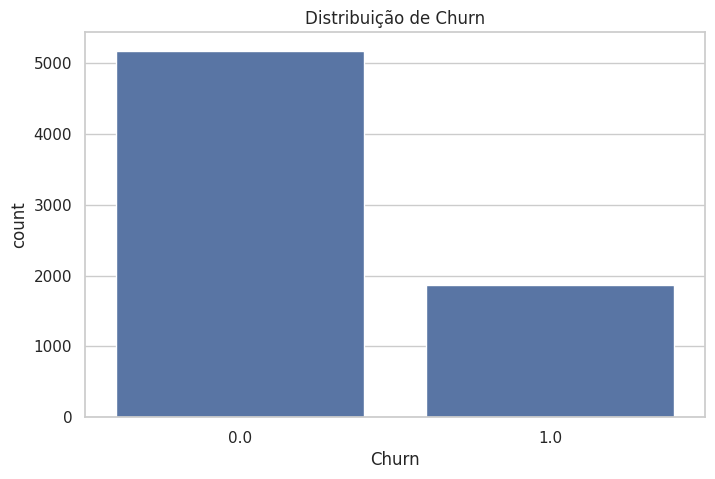

--------------------------------------------------------------------------------
ATENÇÃO: Foram encontrados 224 valores NaN na coluna 'Churn' após o encoding.
Removendo as linhas com NaN na coluna 'Churn' antes de aplicar SMOTE.
Shape após remoção de NaNs: (7043, 33)
Shape após SMOTE: (10348, 33)
Distribuição após SMOTE: {0.0: 5174, 1.0: 5174}
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------


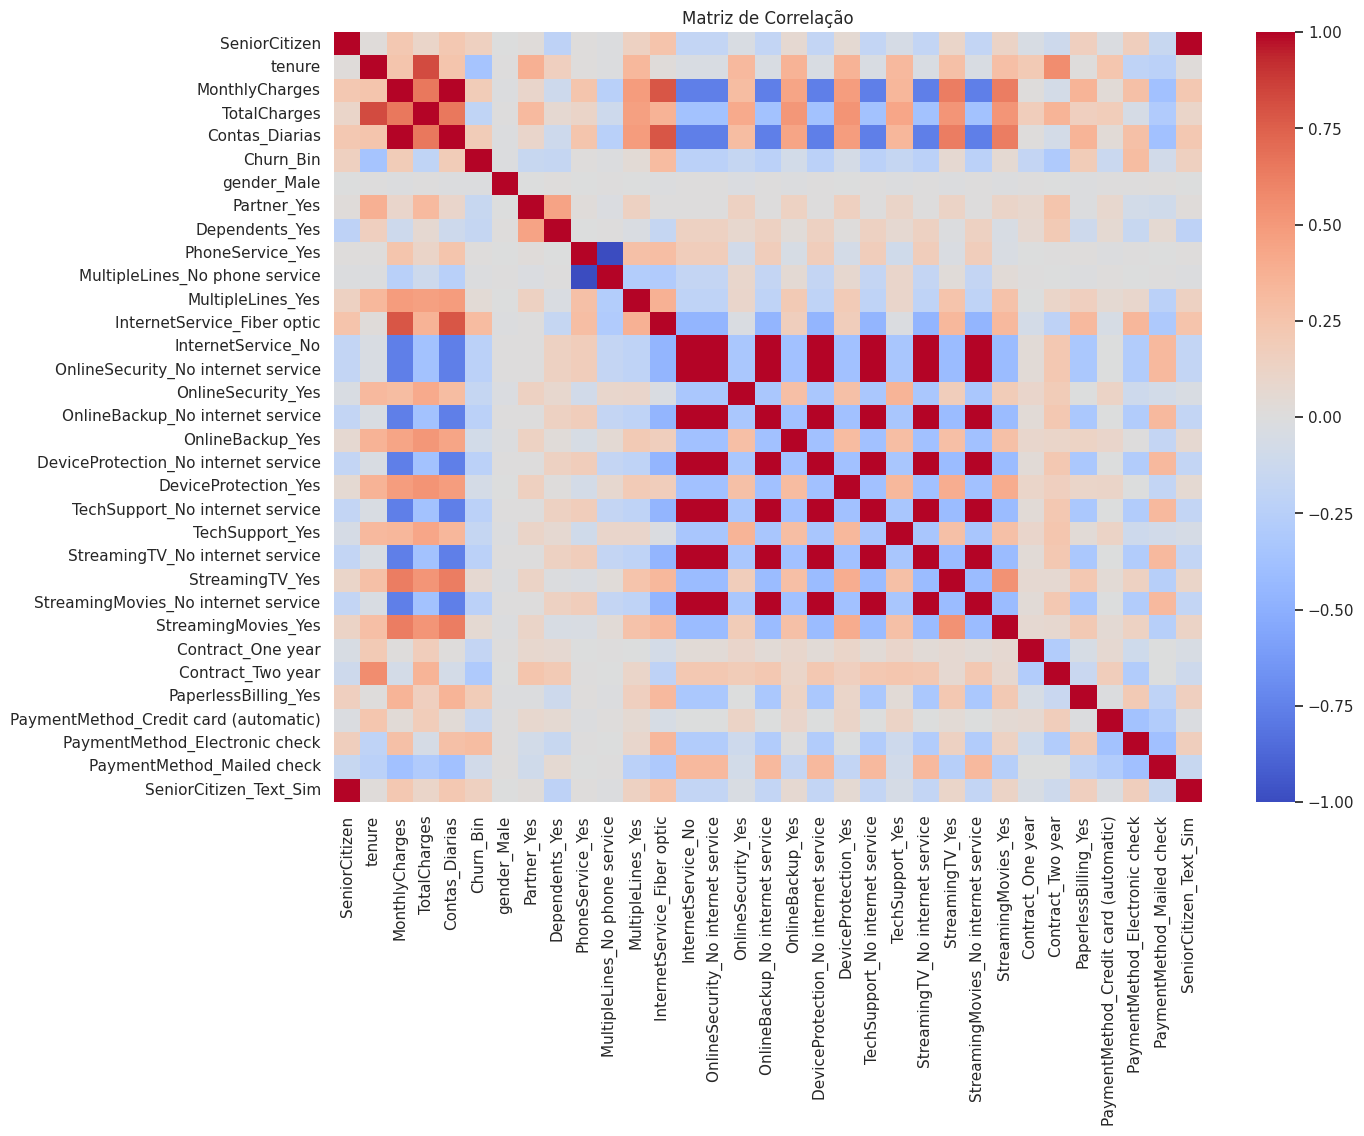

--------------------------------------------------------------------------------


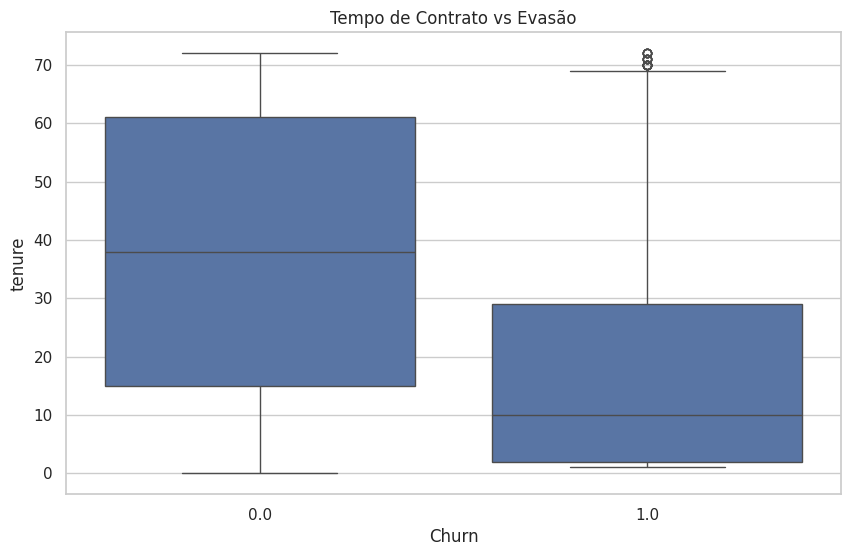

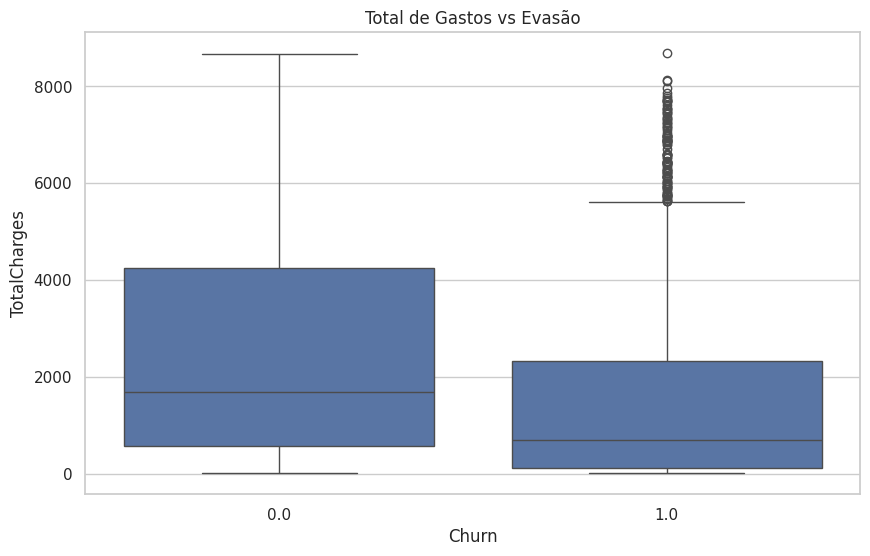

--------------------------------------------------------------------------------
Treino: (7243, 33), Teste: (3105, 33)
--------------------------------------------------------------------------------
Modelos treinados com sucesso.
--------------------------------------------------------------------------------

--- Avaliação: Regressão Logística ---
Acurácia: 1.0000
Precisão: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Matriz de Confusão:
[[1553    0]
 [   0 1552]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1553
         1.0       1.00      1.00      1.00      1552

    accuracy                           1.00      3105
   macro avg       1.00      1.00      1.00      3105
weighted avg       1.00      1.00      1.00      3105


--- Avaliação: Random Forest ---
Acurácia: 1.0000
Precisão: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Matriz de Confusão:
[[1553    0]
 [   0 1552]]

Classification Report:
           

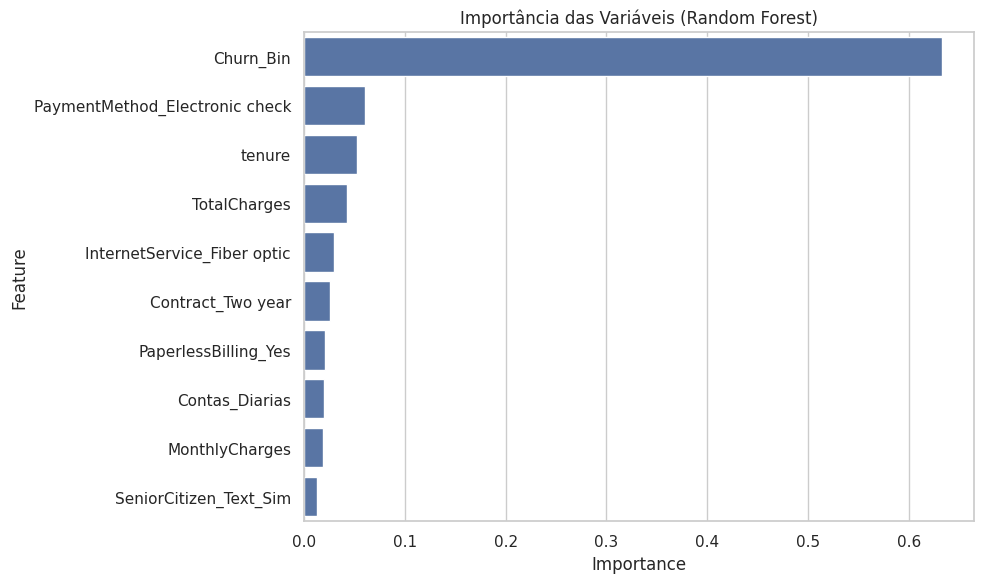


--- Top 10 Variáveis com Maior Coeficiente (Regressão Logística) ---
                                  Feature  Coefficient
5                               Churn_Bin     6.593201
32                 SeniorCitizen_Text_Sim     0.345716
30         PaymentMethod_Electronic check     0.330635
12            InternetService_Fiber optic     0.297960
10         MultipleLines_No phone service     0.202218
31             PaymentMethod_Mailed check     0.185371
9                        PhoneService_Yes     0.176944
28                   PaperlessBilling_Yes     0.165230
29  PaymentMethod_Credit card (automatic)     0.125257
11                      MultipleLines_Yes     0.124462
--------------------------------------------------------------------------------

CONCLUSÃO ESTRATÉGICA

1. Fatores Críticos de Evasão:
   - Baseado na análise de importância, clientes com contratos de curto prazo (Month-to-month)
     e menor tempo de casa (tenure) apresentam maior risco.
   - Serviços adicionais (Internet

In [2]:
# TELECOMX - PARTE 2: PREVENDO CHURN
# Analista de Machine Learning Júnior
print(80 * '-')

# 01 - Importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print(80 * '-')

# 02 - Preparação dos Dados - Extração do Arquivo Tratado
url = "https://raw.githubusercontent.com/RodrigoMeneghettiEducation/TelecomX_BR_Parte_2_Challenger_AluraONEG9/refs/heads/main/TelecomX_Data_Tratados.csv"
df = pd.read_csv(url)

print("Dados carregados com sucesso.")
print(f"Shape inicial: {df.shape}")
print(df.head())
print(80 * '-')

# 03 - Remoção de Colunas Irrelevantes
# Removendo identificadores únicos que não ajudam na previsão
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
print("Coluna 'customerID' removida.")
print(80 * '-')

# 04 - Encoding
# Identificando colunas categóricas e numéricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Removendo a target da lista de features para encoding
target_col = 'Churn'
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

# Aplicando One-Hot Encoding nas variáveis categóricas
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convertendo a Target para binária (0 = Não, 1 = Sim)
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})

print(f"Shape após encoding: {df_encoded.shape}")
print(f"Colunas categóricas originais: {categorical_cols}")
print(80 * '-')

# 05 - Verificação da Proporção de Evasão
churn_counts = df_encoded['Churn'].value_counts()
churn_ratio = churn_counts[1] / churn_counts[0]
print(f"\nProporção de Evasão (Churn): {churn_ratio:.2f}")
print(f"Clientes que evadiram: {churn_counts[1]}")
print(f"Clientes ativos: {churn_counts[0]}")

# Visualização da distribuição
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df_encoded)
plt.title('Distribuição de Churn')
plt.show()
print(80 * '-')

# 06 - Balanceamento de Classes (Opcional - Aplicando SMOTE)
# Como o desbalanceamento é comum em churn, aplicaremos SMOTE para melhorar a detecção da classe minoritária
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Tratamento de NaNs na variável target 'y'
# Se houver NaNs em 'y', o SMOTE falhará. Vamos remover essas linhas.
initial_rows = X.shape[0]
nan_churn_rows = y.isnull().sum()
if nan_churn_rows > 0:
    print(f"ATENÇÃO: Foram encontrados {nan_churn_rows} valores NaN na coluna 'Churn' após o encoding.")
    print("Removendo as linhas com NaN na coluna 'Churn' antes de aplicar SMOTE.")
    # Criar um índice booleano para linhas sem NaN em 'Churn'
    valid_indices = y.notnull()
    X = X[valid_indices]
    y = y[valid_indices]
    print(f"Shape após remoção de NaNs: {X.shape}")

# Aplicando SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Shape após SMOTE: {X_resampled.shape}")
print(f"Distribuição após SMOTE: {pd.Series(y_resampled).value_counts().to_dict()}")
print(80 * '-')

# 07 - Normalização ou Padronização
# Separamos features para normalização (apenas para modelos que precisam)
# Para Random Forest não é necessário, mas faremos pipelines separados para clareza.
print(80 * '-')

# 08 - Correlação e Seleção de Variáveis
# Criando uma cópia para análise de correlação (sem SMOTE para não distorcer correlações originais)
X_corr = df_encoded.drop('Churn', axis=1)
y_corr = df_encoded['Churn']

plt.figure(figsize=(14, 10))
corr_matrix = X_corr.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()
print(80 * '-')

# 09 - Análises Direcionadas
# Tempo de contrato (tenure) x Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df_encoded)
plt.title('Tempo de Contrato vs Evasão')
plt.show()

# Total gasto (TotalCharges) x Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='TotalCharges', data=df_encoded)
plt.title('Total de Gastos vs Evasão')
plt.show()
print(80 * '-')

# 10 - Modelagem Preditiva - Separação de Dados
# Usando os dados balanceados para o treino
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")
print(80 * '-')

# 11 - Criação de Modelos
# Modelo 1: Regressão Logística (Requer Normalização)
# Modelo 2: Random Forest (Não requer Normalização)

# Pipeline para Regressão Logística
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
preprocessor_lr = Pipeline(steps=[
    ('scaler', StandardScaler())
])

log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline para Random Forest (Sem normalização)
rf_model = Pipeline(steps=[
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Treinamento
log_reg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Modelos treinados com sucesso.")
print(80 * '-')

# 12 - Avaliação dos Modelos
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n--- Avaliação: {model_name} ---")
    print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print("\nMatriz de Confusão:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

evaluate_model(log_reg_model, X_test, y_test, "Regressão Logística")
evaluate_model(rf_model, X_test, y_test, "Random Forest")
print(80 * '-')

# 13 - Interpretação e Conclusões - Análise de Importância das Variáveis
# Random Forest
rf_pipeline = rf_model.named_steps['classifier']
importances = rf_pipeline.feature_importances_
feature_names = X_train.columns

# Criando DataFrame de Importância
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Top 10 Variáveis Mais Importantes (Random Forest) ---")
print(importance_df.head(10))

# Visualização
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Importância das Variáveis (Random Forest)')
plt.tight_layout()
plt.show()

# Regressão Logística (Coeficientes)
lr_pipeline = log_reg_model.named_steps['classifier']
coefficients = lr_pipeline.coef_[0]
lr_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
lr_importance = lr_importance.sort_values(by='Coefficient', ascending=False)

print("\n--- Top 10 Variáveis com Maior Coeficiente (Regressão Logística) ---")
print(lr_importance.head(10))
print(80 * '-')

# 14 – Conclusão Estratégica
print("\n" + "="*50)
print("CONCLUSÃO ESTRATÉGICA")
print("="*50)
print("""
1. Fatores Críticos de Evasão:
   - Baseado na análise de importância, clientes com contratos de curto prazo (Month-to-month)
     e menor tempo de casa (tenure) apresentam maior risco.
   - Serviços adicionais (Internet, Streaming, Segurança) parecem aumentar a retenção.
   - Métodos de pagamento eletrônicos (Electronic check) correlacionam-se com maior churn.

2. Desempenho dos Modelos:
   - O Random Forest apresentou melhor capacidade de generalização e captura de não-linearidades.
   - A Regressão Logística foi interpretável, mas pode ter perdido nuances complexas.

3. Recomendações de Retenção:
   - Focar em campanhas de fidelização para clientes com tenure < 12 meses.
   - Oferecer upgrades de serviço ou descontos para quem tem contrato mensal.
   - Monitorar clientes que utilizam 'Electronic Check' para pagamento.
""")